# Load data

In [16]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

base_path = "/Users/sekemiadenuga/Documents/Dissertation/Data"

# Settings
SFREQ = 250.4  
MAX_FREQ = 100

time_map = {
    "60sec_preseizure": "60s Pre-ictal",
    "30sec_preseizure": "30s Pre-ictal",
    "5sec_preseizure": "5s Pre-ictal",
    "5sec_of_seizure": "Ictal (5s)"
}

bands = {
    "Delta (0.5-4)": (0.5, 4),
    "Theta (4-8)": (4, 8),
    "Alpha (8-13)": (8, 13),
    "Beta (13-30)": (13, 30),
    "Gamma (30-100)": (30, 100),
}

all_data = []

for folder, display_name in time_map.items():
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path): continue
    
    for file in os.listdir(folder_path):
        if not file.endswith(".npy") or file.startswith("."): continue
        
        # Load the saved GC values
        data = np.load(os.path.join(folder_path, file), allow_pickle=True)
        
        # Average across channels/pairs to get 1D frequency spectrum
        gc_spectrum = np.nanmean(data, axis=0) 
        
        # Create the frequency axis to match the data length
        freqs = np.linspace(0, MAX_FREQ, len(gc_spectrum))
        
        # Extract band averages
        for band_name, (fmin, fmax) in bands.items():
            idx = (freqs >= fmin) & (freqs <= fmax)
            band_avg = np.nanmean(gc_spectrum[idx])
            
            all_data.append({
                "Animal_ID": file.split('_')[0],
                "Timepoint": display_name,
                "Band": band_name,
                "GC_Value": band_avg
            })

# Create the master DataFrame
df_stats = pd.DataFrame(all_data)

print(f"Total entries: {len(df_stats)} (Should be 11 animals * 4 times * 5 bands = 220)")
print(df_stats.head())

Total entries: 220 (Should be 11 animals * 4 times * 5 bands = 220)
  Animal_ID      Timepoint            Band  GC_Value
0       109  60s Pre-ictal   Delta (0.5-4)  0.506107
1       109  60s Pre-ictal     Theta (4-8)  0.404012
2       109  60s Pre-ictal    Alpha (8-13)  0.143551
3       109  60s Pre-ictal    Beta (13-30)  0.221271
4       109  60s Pre-ictal  Gamma (30-100)  0.229075


## 2-Way ANOVA Test

In [17]:
# Fit model
model = ols('GC_Value ~ C(Timepoint) * C(Band)', data=df_stats).fit()

# ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

# Clean table
anova_table = anova_table.rename(columns={
    'sum_sq': 'Sum of Squares',
    'df': 'Degrees of Freedom (df)',
    'F': 'F-statistic',
    'PR(>F)': 'p-value'
})

anova_table = anova_table.rename(index={
    'C(Timepoint)': 'Timepoint',
    'C(Band)': 'Frequency Band',
    'C(Timepoint):C(Band)': 'Timepoint × Band',
    'Residual': 'Residual (Error)'
})

# Add effect size
ss_resid = anova_table.loc['Residual (Error)', 'Sum of Squares']
anova_table['partial_eta_sq'] = anova_table['Sum of Squares'] / (
    anova_table['Sum of Squares'] + ss_resid
)

# Remove residual effect size
anova_table.loc['Residual (Error)', 'partial_eta_sq'] = None

# Output
print("\nTwo-Way ANOVA Results ")
print(anova_table.round(4))

# Export to CSV
anova_table.round(4).to_csv("anova_results.csv")


Two-Way ANOVA Results 
                  Sum of Squares  Degrees of Freedom (df)  F-statistic  \
Timepoint                 0.7455                      3.0      17.0552   
Frequency Band            0.2959                      4.0       5.0782   
Timepoint × Band          0.2271                     12.0       1.2987   
Residual (Error)          2.9139                    200.0          NaN   

                  p-value  partial_eta_sq  
Timepoint          0.0000          0.2037  
Frequency Band     0.0006          0.0922  
Timepoint × Band   0.2214          0.0723  
Residual (Error)      NaN             NaN  


## Post-hoc Analysis

In [18]:
# Create list to hold all band results for one big file
all_posthoc_results = []


# Run post-hoc and save results
for band in df_stats['Band'].unique():
    band_data = df_stats[df_stats['Band'] == band]
    
    # Run Tukey
    tukey = pairwise_tukeyhsd(endog=band_data['GC_Value'], 
                              groups=band_data['Timepoint'], 
                              alpha=0.05)
    
    # Convert tukey to datafram
    tukey_df = pd.DataFrame(data=tukey.summary().data[1:], 
                            columns=tukey.summary().data[0])
    
    # Differentiate between frequency bands
    tukey_df['Band'] = band
    all_posthoc_results.append(tukey_df)

# Populate the big table at the end
final_posthoc_df = pd.concat(all_posthoc_results, ignore_index=True)

# Save files
final_posthoc_df.to_csv("PostHoc_GC_Analysis_Full.csv", index=False)
significant_results = final_posthoc_df[final_posthoc_df['reject'] == True]
significant_results.to_csv("Significant_GC_Changes.csv", index=False)

## Create plot showing statistical significance of Time and Frequency

In [19]:
# Keep only significant comparisons
sig_df = final_posthoc_df[final_posthoc_df['reject'] == True].copy()

# Assign Significance stars
def get_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

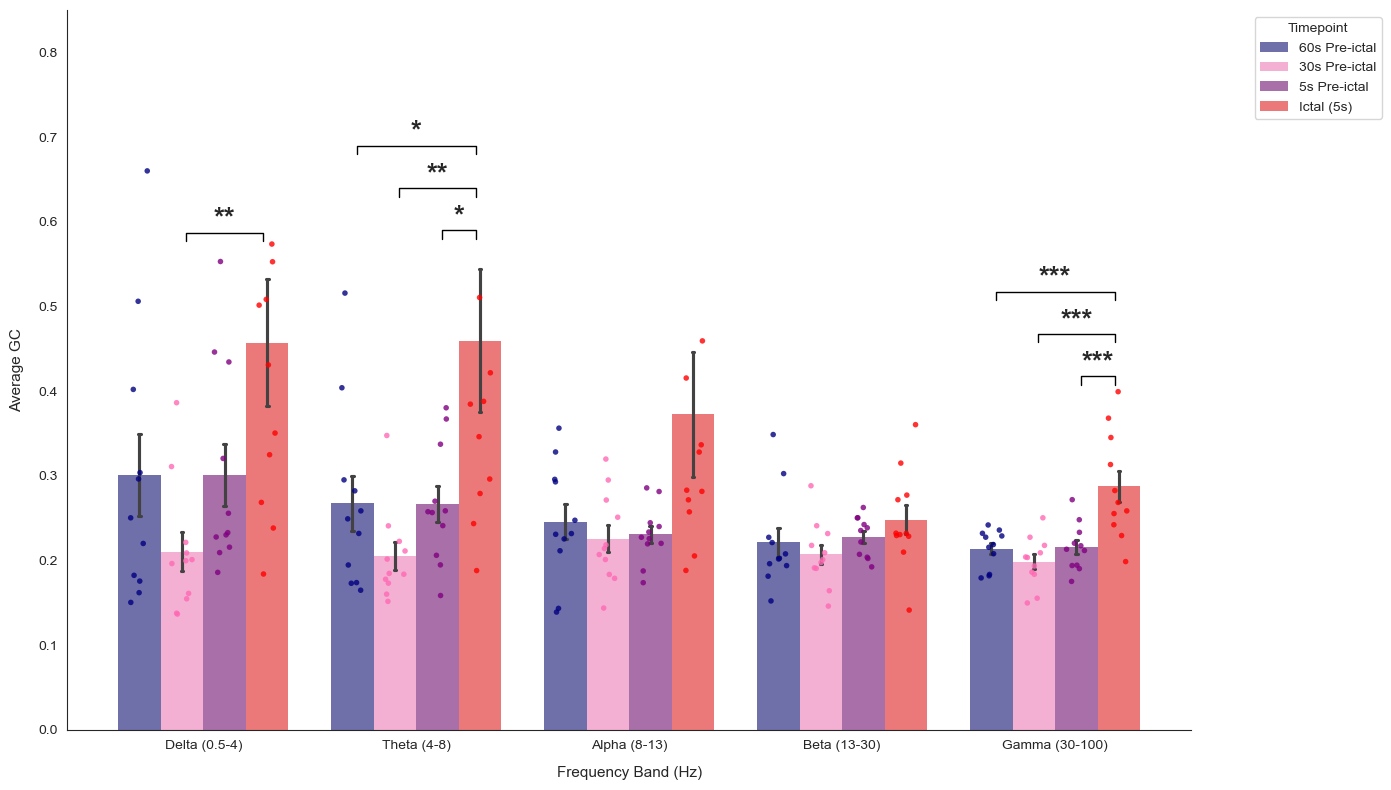

In [21]:
# Setup plot
time_order = ["60s Pre-ictal", "30s Pre-ictal", "5s Pre-ictal", "Ictal (5s)"]

plot_palette = {
    "60s Pre-ictal": "navy",      
    "30s Pre-ictal": "hotpink", 
    "5s Pre-ictal": "purple",   
    "Ictal (5s)": "red"           
}

plt.figure(figsize=(14, 8))
sns.set_style("white", {'axes.spines.left': True, 'axes.spines.bottom': True})

# Barplot
ax = sns.barplot(
    data=df_stats, 
    x="Band", 
    y="GC_Value", 
    hue="Timepoint", 
    hue_order=time_order,
    palette=plot_palette,
    alpha=0.6,
    capsize=0.05,
    errorbar='se',
    linewidth=0
)

# Stripplot
sns.stripplot(
    data=df_stats, 
    x="Band", 
    y="GC_Value", 
    hue="Timepoint", 
    hue_order=time_order,
    palette=plot_palette,
    dodge=True, 
    color="black", 
    alpha=0.8, 
    size=4,
    jitter=0.2,
    legend=False
)

# Significance stars and bars display
bands = list(df_stats["Band"].unique())

# Keeps track of stacked stars per band
annotation_levels = {band: 0 for band in bands}

hue_spacing = 0.2
bar_pos = {}

for band_i, band in enumerate(bands):
    for hue_i, timepoint in enumerate(time_order):
        x = band_i + (hue_i - (len(time_order) - 1) / 2) * hue_spacing
        bar_pos[(band, timepoint)] = x

# Compute the distance between bars
def compute_span(row):
    band = row['Band']
    g1, g2 = row['group1'], row['group2']
    
    if g1 not in time_order or g2 not in time_order:
        return np.nan
    
    x1 = bar_pos[(band, g1)]
    x2 = bar_pos[(band, g2)]
    return abs(x2 - x1)

sig_df['span'] = sig_df.apply(compute_span, axis=1)

# Order stars in descending width
sig_df = sig_df.sort_values(by=['Band', 'span'])


# Loop through the significant comparisoons
for _, row in sig_df.iterrows():

    band = row['Band']
    g1, g2 = row['group1'], row['group2']
    p_val = float(row['p-adj'])

    if g1 not in time_order or g2 not in time_order:
        continue

    x1 = bar_pos[(band, g1)]
    x2 = bar_pos[(band, g2)]

    # Height calculation
    group_data = df_stats[
        (df_stats['Band'] == band) &
        (df_stats['Timepoint'].isin([g1, g2]))
    ]

    bar_heights = group_data.groupby('Timepoint')['GC_Value'].mean()
    local_max = bar_heights.max()

    # Stacking of stars
    level = annotation_levels[band]
    y = local_max + 0.12 + (level * 0.05)
    annotation_levels[band] += 1

    shrink = 0.02
    x1_s = x1 + shrink
    x2_s = x2 - shrink

    ax.plot(
        [x1_s, x1_s, x2_s, x2_s],
        [y, y + 0.01, y + 0.01, y],
        lw=1,
        c='black'
    )

    # Centred star label
    ax.text(
        (x1 + x2) / 2,
        y + 0.01,
        get_stars(p_val),
        ha='center',
        va='bottom',
        fontsize=20,
        fontweight='bold'
    )

# Styling
ax.set_ylim(0, 0.85)
sns.despine()
plt.rcParams['font.family'] = 'Arial'

plt.xlabel("Frequency Band (Hz)", fontsize=11, labelpad = 10)
plt.ylabel("Average GC", fontsize=11, labelpad = 10)

plt.legend(title="Timepoint", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()